In [5]:
import os
import requests
import zipfile
import io

# --- Configuration ---
from getpass import getpass
GITHUB_TOKEN = os.environ.get("GITHUB_TOKEN") or getpass("GITHUB_TOKEN not found in environment. Enter token: ")
REPO_OWNER    = "hoanlenguyen"
REPO_NAME     = "SeminarDemo"
ARTIFACT_NAME = "xunit-test-report"
OUTPUT_XML    = "test_results.xml"


headers = {
    "Authorization": f"Bearer {GITHUB_TOKEN}",
    "Accept": "application/vnd.github+json",
    "X-GitHub-Api-Version": "2022-11-28"
}

# --- Step 1: Find the latest artifact by name ---
print(f"Fetching artifacts from {REPO_OWNER}/{REPO_NAME}...")
resp = requests.get(
    f"https://api.github.com/repos/{REPO_OWNER}/{REPO_NAME}/actions/artifacts",
    headers=headers,
    params={"name": ARTIFACT_NAME, "per_page": 1}
)
resp.raise_for_status()
artifacts = resp.json().get("artifacts", [])

if not artifacts:
    raise FileNotFoundError(f'No artifact named "{ARTIFACT_NAME}" found in {REPO_OWNER}/{REPO_NAME}.')

artifact = artifacts[0]
artifact_id = artifact["id"]
print(f"Found: {artifact['name']} (id={artifact_id}, created={artifact['created_at']})")

# --- Step 2: Download the artifact zip ---
print("Downloading artifact zip...")
download_resp = requests.get(
    f"https://api.github.com/repos/{REPO_OWNER}/{REPO_NAME}/actions/artifacts/{artifact_id}/zip",
    headers=headers,
    allow_redirects=True
)
download_resp.raise_for_status()
print(f"Downloaded {len(download_resp.content):,} bytes")

# --- Step 3: Unzip and extract test_results.xml ---
print(f"Extracting {OUTPUT_XML}...")
with zipfile.ZipFile(io.BytesIO(download_resp.content)) as zf:
    print(f"Files in zip: {zf.namelist()}")
    zf.extract(OUTPUT_XML, path=".")

print(f"Done. {OUTPUT_XML} is ready for analysis.")


Fetching artifacts from hoanlenguyen/SeminarDemo...
Found: xunit-test-report (id=6476133792, created=2026-04-16T14:45:24Z)
Downloaded 206,272 bytes
Extracting test_results.xml...
Files in zip: ['test_results.xml']
Done. test_results.xml is ready for analysis.


In [6]:
import xml.etree.ElementTree as ET
import pandas as pd
import os

def parse_xunit_xml_to_csv(xml_folder, output_csv_path):
    """
    Parses xUnit XML reports and extracts test names, durations, and outcomes.
    Test type is determined by the test class name:
      - MockUnitTests     -> Mocked_Dependency_Tests  (uses Moq, no real DB)
      - StandardUnitTests -> Standard_Tests           (uses EF Core InMemoryDatabase)
    """
    extracted_data = []

    for filename in os.listdir(xml_folder):
        if filename.endswith(".xml"):
            file_path = os.path.join(xml_folder, filename)
            try:
                tree = ET.parse(file_path)
                root = tree.getroot()
                for test_case in root.iter("test"):
                    test_name = test_case.attrib.get("name", "Unknown_Test")
                    execution_time = float(test_case.attrib.get("time", 0.0))
                    result = test_case.attrib.get("result", "Pass")

                    # MockUnitTests uses Moq -> Mocked_Dependency_Tests
                    # StandardUnitTests uses EF Core InMemoryDatabase -> Standard_Tests
                    if "MockUnitTests" in test_name:
                        test_type = "Mocked_Dependency_Tests"
                    elif "StandardUnitTests" in test_name:
                        test_type = "Standard_Tests"
                    else:
                        test_type = "Other"

                    extracted_data.append({
                        "Run_Source": filename,
                        "Test_Name": test_name,
                        "Test_Type": test_type,
                        "Execution_Time_Seconds": execution_time,
                        "Execution_Time_Milliseconds": execution_time * 1000,
                        "Result": result
                    })
            except ET.ParseError:
                print(f"Error parsing {filename}")

    if extracted_data:
        df = pd.DataFrame(extracted_data)
        df.to_csv(output_csv_path, index=False)
        print(f"Successfully extracted {len(df)} test records to {output_csv_path}")
        print("\n--- Quick Summary ---")
        print(df.groupby("Test_Type")["Execution_Time_Milliseconds"].agg(["mean", "median", "std", "count"]).round(3))
    else:
        print("No test data found. Check your XML files.")

xml_input_directory = "./"
csv_output_file = "tdd_execution_dataset.csv"
print(f"Looking for XML files in: {os.path.abspath(xml_input_directory)}")
parse_xunit_xml_to_csv(xml_input_directory, csv_output_file)


Looking for XML files in: d:\Study\20. Project Seminar\SeminarDemo\github_reports
Successfully extracted 20000 test records to tdd_execution_dataset.csv

--- Quick Summary ---
                          mean  median     std  count
Test_Type                                            
Mocked_Dependency_Tests  0.556   0.452   1.205  10000
Standard_Tests           0.800   0.631  13.797  10000


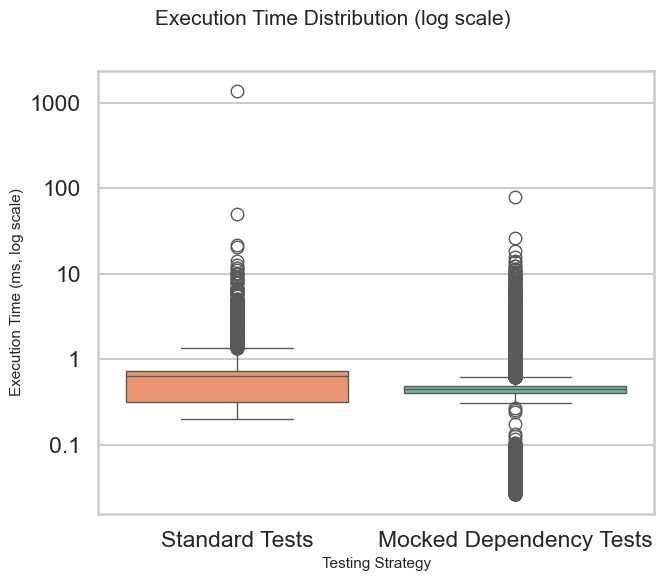

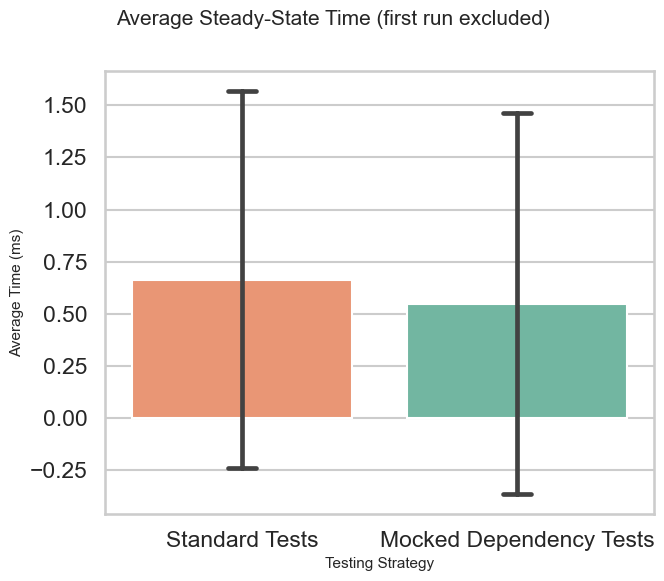

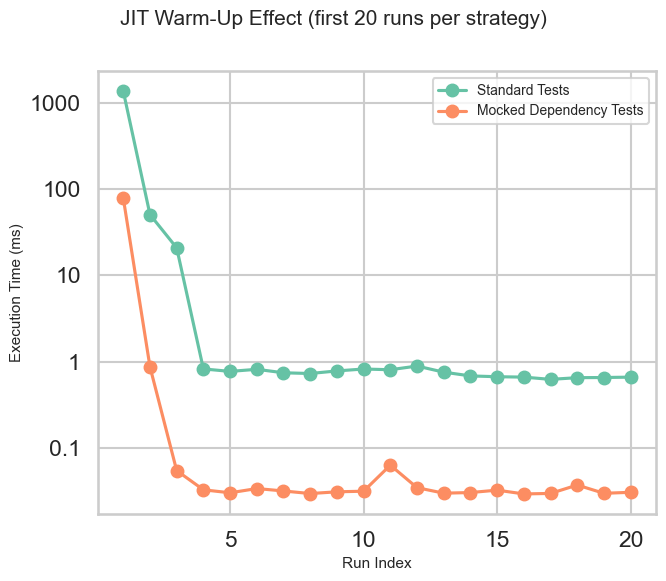

--- Full Distribution (all runs, including warm-up) ---
                          mean  median     std    min       max  count
Test_Type                                                             
Mocked_Dependency_Tests  0.556   0.452   1.205  0.027    78.954  10000
Standard_Tests           0.800   0.631  13.797  0.200  1377.399  10000

--- Steady-State (first run excluded per test type) ---
                          mean  median    std    min     max  count
Test_Type                                                          
Mocked_Dependency_Tests  0.548   0.452  0.915  0.027  26.577   9999
Standard_Tests           0.662   0.631  0.907  0.200  50.757   9999


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

df = pd.read_csv("tdd_execution_dataset.csv")
sns.set_theme(style="whitegrid", context="talk")

# Category order and display labels
order = ["Standard_Tests", "Mocked_Dependency_Tests"]
labels = {
    "Standard_Tests":          "Standard Tests",
    "Mocked_Dependency_Tests": "Mocked Dependency Tests"
}
df["Test_Label"] = df["Test_Type"].map(labels)
label_order = [labels[o] for o in order]

# Steady-state data (first run excluded per test type)
df_sorted = df[df["Test_Type"].isin(order)].copy()
df_sorted["row_idx"] = df_sorted.groupby("Test_Type").cumcount()
df_steady = df_sorted[df_sorted["row_idx"] > 0]

# JIT warm-up data (first 20 runs per test type)
top_n = 20
warmup_frames = []
for ttype in order:
    subset = df[df["Test_Type"] == ttype].head(top_n).copy()
    subset["Run_Index"] = range(1, len(subset) + 1)
    warmup_frames.append(subset)
df_warmup = pd.concat(warmup_frames)

# --- Chart 1: Box plot with log scale ---
fig1, ax1 = plt.subplots(figsize=(7, 6))
fig1.suptitle("Execution Time Distribution (log scale)", fontsize=15)
sns.boxplot(
    data=df[df["Test_Type"].isin(order)],
    x="Test_Label", y="Execution_Time_Milliseconds",
    hue="Test_Label", order=label_order, legend=False, ax=ax1, palette="Set2"
)
ax1.set_yscale("log")
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:g}"))
ax1.set_xlabel("Testing Strategy", fontsize=11)
ax1.set_ylabel("Execution Time (ms, log scale)", fontsize=11)
plt.tight_layout()
plt.savefig("chart1_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Chart 2: Bar plot - steady-state average (warm-up run excluded) ---
fig2, ax2 = plt.subplots(figsize=(7, 6))
fig2.suptitle("Average Steady-State Time (first run excluded)", fontsize=15)
sns.barplot(
    data=df_steady,
    x="Test_Label", y="Execution_Time_Milliseconds",
    hue="Test_Label", order=label_order, legend=False, estimator="mean", errorbar="sd",
    capsize=0.1, ax=ax2, palette="Set2"
)
ax2.set_xlabel("Testing Strategy", fontsize=11)
ax2.set_ylabel("Average Time (ms)", fontsize=11)
plt.tight_layout()
plt.savefig("chart2_steady_state.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Chart 3: JIT warm-up - first 20 runs per test type ---
fig3, ax3 = plt.subplots(figsize=(7, 6))
fig3.suptitle(f"JIT Warm-Up Effect (first {top_n} runs per strategy)", fontsize=15)
for ttype, color in zip(order, sns.color_palette("Set2")):
    subset = df_warmup[df_warmup["Test_Type"] == ttype]
    ax3.plot(
        subset["Run_Index"], subset["Execution_Time_Milliseconds"],
        marker="o", label=labels[ttype], color=color
    )
ax3.set_xlabel("Run Index", fontsize=11)
ax3.set_ylabel("Execution Time (ms)", fontsize=11)
ax3.legend(fontsize=10)
ax3.set_yscale("log")
ax3.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:g}"))
plt.tight_layout()
plt.savefig("chart3_jit_warmup.png", dpi=150, bbox_inches="tight")
plt.show()

print("--- Full Distribution (all runs, including warm-up) ---")
full = df[df["Test_Type"].isin(order)].groupby("Test_Type")["Execution_Time_Milliseconds"] \
    .agg(["mean", "median", "std", "min", "max", "count"]).round(3)
print(full.to_string())

print("\n--- Steady-State (first run excluded per test type) ---")
steady = df_steady.groupby("Test_Type")["Execution_Time_Milliseconds"] \
    .agg(["mean", "median", "std", "min", "max", "count"]).round(3)
print(steady.to_string())
